# QAOA for UAV Swarm Deployment — ISAC-Assisted Disaster Relief

**Run cells top to bottom. Each cell is self-contained within the shared kernel.**


# ENVIRONMENT 



In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

# ── Physical constants ────────────────────────────────────────────────
C_LIGHT = 3.0e8
LN2_VAL = np.log(2)


U  = 4      # UAVs
G  = 6      # Grid points
S  = 6      # Survivors
Nt = 64     # Antennas per UAV (ULA) — does NOT affect qubit count

# ── RF parameters ─────────────────────────────────────────────────────
fc       = 2.4e9    # carrier frequency [Hz]
B        = 1e6      # bandwidth [Hz]
P_max    = 1.0      # max transmit power [W]

# ── Rician channel ────────────────────────────────────────────────────
kappa    = 3.0      # K-factor
a_itu    = 9.61     # ITU-R LoS constant a
b_itu    = 0.16     # ITU-R LoS constant b
eta_LoS  = 1.0      # LoS  attenuation [linear]
eta_NLoS = 20.0     # NLoS attenuation [linear]

# ── QUBO penalties ────────────────────────────────────────────────────
d_safe    = 10.0    # min UAV separation [m] (eq:c4)
SEED      = 42

N_QUBITS  = U * G
print(f"U={U} UAVs | G={G} grid pts | S={S} survivors | Nt={Nt} antennas")
print(f"Qubits n = U×G = {N_QUBITS}")
print(f"Statevector memory ≈ {2**N_QUBITS * 16 / 1e9:.3f} GB")

# ─────────────────────────────────────────────────────────────────────
# Channel geometry functions
# ─────────────────────────────────────────────────────────────────────
def elevation(pg, qs):
    d = pg - qs
    return float(np.arctan2(d[2], np.sqrt(d[0]**2 + d[1]**2)))

def azimuth(pg, qs):
    d = qs - pg
    return float(np.arctan2(d[1], d[0]))

def plos(theta):
    return float(1.0 / (1.0 + a_itu * np.exp(-b_itu*(np.degrees(theta)-a_itu))))

def path_loss(pg, qs):
    d   = float(np.linalg.norm(pg - qs))
    th  = elevation(pg, qs)
    Pl  = plos(th)
    return float((C_LIGHT / (4*np.pi*fc*d))**2 / (Pl*eta_LoS + (1-Pl)*eta_NLoS))

def steering(theta, phi):
    inc = np.pi * np.sin(theta) * np.cos(phi)
    return (1/np.sqrt(Nt)) * np.exp(1j * inc * np.arange(Nt))

def channel_vec(pg, qs, rng):
    L   = path_loss(pg, qs)
    th  = elevation(pg, qs)
    phi = azimuth(pg, qs)
    a   = steering(th, phi)
    ht  = (rng.standard_normal(Nt) + 1j*rng.standard_normal(Nt)) / np.sqrt(2)
    return np.sqrt(L) * (np.sqrt(kappa/(kappa+1))*a + np.sqrt(1/(kappa+1))*ht)

def mrt(h):
    return np.sqrt(P_max) * h / np.linalg.norm(h)

def sg(h, w):
    v = np.vdot(h, w); return float(np.real(v*np.conj(v)))

def ig(h_vgp, w_ug):
    v = np.vdot(h_vgp, w_ug); return float(np.real(v*np.conj(v)))

# ─────────────────────────────────────────────────────────────────────
# Build 3-D grid and survivors
# ─────────────────────────────────────────────────────────────────────
rng_env = np.random.default_rng(SEED)
p_grid  = np.hstack([rng_env.uniform(0, 500, (G,2)),
                     rng_env.uniform(50, 150, (G,1))])   # UAV positions
q_surv  = np.hstack([rng_env.uniform(0, 500, (S,2)),
                     np.zeros((S,1))])                    # ground-level survivors


# ─────────────────────────────────────────────────────────────────────
H = np.zeros((U,G,S,Nt), dtype=np.complex128)
W = np.zeros((U,G,S,Nt), dtype=np.complex128)
for u in range(U):
    for g in range(G):
        for s in range(S):
            H[u,g,s] = channel_vec(p_grid[g], q_surv[s], rng_env)
            W[u,g,s] = mrt(H[u,g,s])

G_table = np.array([[[sg(H[u,g,s], W[u,g,s])
                       for s in range(S)] for g in range(G)] for u in range(U)])

I_table = np.zeros((U,G,U,G,S))
for u in range(U):
    for g in range(G):
        for v in range(U):
            for gp in range(G):
                if (u,g)==(v,gp): continue
                for s in range(S):
                    I_table[u,g,v,gp,s] = ig(H[v,gp,s], W[u,g,s])

# ─────────────────────────────────────────────────────────────────────
# Calibrated noise floor σ²
#

# ─────────────────────────────────────────────────────────────────────
TARGET_MAX_SINR = 0.5
sigma2 = float(G_table.max() / TARGET_MAX_SINR)
print(f"\nCalibrated σ² = {sigma2:.4e} W "
      f"(target max single-link SINR = {TARGET_MAX_SINR})")

# ─────────────────────────────────────────────────────────────────────
# Rate linearisation coefficients  (eq:acoeff / eq:bcoeff)
# ─────────────────────────────────────────────────────────────────────
a_coeff = G_table / (sigma2 * LN2_VAL)

b_coeff = np.zeros((U,G,U,G,S))
denom   = sigma2**2 * LN2_VAL**2
for u in range(U):
    for g in range(G):
        for v in range(U):
            for gp in range(G):
                if (u,g)==(v,gp): continue
                b_coeff[u,g,v,gp,:] = G_table[u,g,:]*I_table[u,g,v,gp,:]/denom

# ─────────────────────────────────────────────────────────────────────
# Calibrated SINR floor Γ_min
# ─────────────────────────────────────────────────────────────────────
max_a_per_survivor = [float(a_coeff[:,:,s].max()) for s in range(S)]
Gamma_min = 0.30 * min(max_a_per_survivor)
print(f"Calibrated Γ_min = {Gamma_min:.5f} "
      f"(30% of worst-case best-achievable survivor gain)")

# ─────────────────────────────────────────────────────────────────────
# Penalty weights  (eq:lambda_hard / eq:lambda_soft)

# ─────────────────────────────────────────────────────────────────────
lam_hard = 1.5 * B * float(np.sum(a_coeff))
lambda1  = lam_hard   # C1: one-hot
lambda2  = lam_hard   # C2: no co-location
lambda3  = 0.01 * lam_hard  # C3: SINR floor (soft)
lambda4  = lam_hard   # C4: collision avoidance

# ─────────────────────────────────────────────────────────────────────
# Exclusion set E  (eq:exclusion)
# ─────────────────────────────────────────────────────────────────────
excl_set = set(
    (g,gp) for g in range(G) for gp in range(G)
    if g!=gp and np.linalg.norm(p_grid[g]-p_grid[gp]) < d_safe
)

# ─────────────────────────────────────────────────────────────────────
# Build QUBO matrix Q  (eq:Qdiag / eq:Qoffdiag)
# Q is symmetric here — matching the example notebook convention
# ─────────────────────────────────────────────────────────────────────
def qi(u,g): return u*G+g

Q = np.zeros((N_QUBITS, N_QUBITS))

for u in range(U):
    for g in range(G):
        i   = qi(u,g)
        sa  = float(np.sum(a_coeff[u,g,:]))
        sa2 = float(np.sum(a_coeff[u,g,:]**2))
        # Diagonal (eq:Qdiag + P3 diagonal correction)
        Q[i,i] = -B*sa - lambda1 - 2*lambda3*Gamma_min*sa + lambda3*sa2

        for v in range(U):
            for gp in range(G):
                if qi(u,g) >= qi(v,gp): continue
                j = qi(v,gp)
                # Interference  (both directions for symmetry)
                it = B*(float(np.sum(b_coeff[u,g,v,gp,:]))
                       +float(np.sum(b_coeff[v,gp,u,g,:])))
                # C1 same UAV diff grid
                c1 = 2*lambda1 if (u==v and g!=gp) else 0.0
                # C2 diff UAV same grid
                c2 = lambda2   if (u!=v and g==gp) else 0.0
                # C3 cross (×2 for all ordered pairs)
                c3 = 2*lambda3*float(np.sum(a_coeff[u,g,:]*a_coeff[v,gp,:]))
                # C4 collision
                c4 = lambda4   if (u!=v and (g,gp) in excl_set) else 0.0
                val = it + c1 + c2 + c3 + c4
                Q[i,j] += val/2; Q[j,i] += val/2   # symmetric

print(f"\nG_table  : {G_table.shape}  range [{G_table.min():.2e}, {G_table.max():.2e}]")
print(f"a_coeff  : {a_coeff.shape}  range [{a_coeff.min():.4f}, {a_coeff.max():.4f}]")
print(f"Q matrix : {Q.shape}  symmetric={np.allclose(Q,Q.T)}")
print(f"|E|      : {len(excl_set)} exclusion pairs")
print(f"λ1=λ2=λ4 : {lambda1:.4e}")
print(f"λ3       : {lambda3:.4e}")

# ─────────────────────────────────────────────────────────────────────
# Evaluation helpers — used in all subsequent cells
# ─────────────────────────────────────────────────────────────────────
def sinr_s(x_mat, s):
    """Exact SINR at survivor s  (eq:sinr)"""
    num = sum(x_mat[u,g]*G_table[u,g,s] for u in range(U) for g in range(G))
    inter = sum(I_table[u,g,v,gp,s]*x_mat[u,g]*x_mat[v,gp]
                for u in range(U) for g in range(G)
                for v in range(U) for gp in range(G)
                if (u,g)!=(v,gp))
    return num / (inter + sigma2)

def sum_rate(x_mat):
    """Exact sum-rate [bps]  (eq:rsum_expanded)"""
    return sum(B*np.log2(1+sinr_s(x_mat,s)) for s in range(S))

def check_constraints(x_vec):
    x = x_vec.reshape(U, G)
    c1 = all(x[u,:].sum()==1  for u in range(U))
    c2 = all(x[:,g].sum()<=1  for g in range(G))
    c3 = all(float(np.sum(a_coeff[:,:,s]*x))>=Gamma_min for s in range(S))
    c4 = all(x[u,g]+x[v,gp]<=1
             for u,v in combinations(range(U),2)
             for g,gp in excl_set)
    return c1, c2, c3, c4

def qubo_val(x_vec):
    """x^T Q x"""
    return float(x_vec @ Q @ x_vec)

# ─────────────────────────────────────────────────────────────────────
# SANITY CHECK — verify that the greedy probe placement is feasible and in the linear regime
# ─────────────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print("  SANITY CHECK — quick greedy probe (diagnostic only)")
print(f"{'─'*60}")
_x_greedy_probe = np.zeros((U,G), dtype=int)
_occupied = set()
for u in range(U):
    best_g, best_r = None, -np.inf
    for g in range(G):
        if g in _occupied:
            continue   # C2 enforcement — skip already-occupied grids
        _x_greedy_probe[u,g] = 1
        r = sum_rate(_x_greedy_probe.astype(float))
        if r > best_r: best_r, best_g = r, g
        _x_greedy_probe[u,g] = 0
    _x_greedy_probe[u, best_g] = 1
    _occupied.add(best_g)
_greedy_probe_rate = sum_rate(_x_greedy_probe.astype(float))
_greedy_probe_qubo = qubo_val(_x_greedy_probe.flatten().astype(float))
_max_sinr_probe = max(sinr_s(_x_greedy_probe.astype(float), s) for s in range(S))
print(f"Greedy-probe true rate : {_greedy_probe_rate/1e6:.4f} Mbps")
print(f"Max SINR observed      : {_max_sinr_probe:.4f}  "
      f"({'OK — in linear regime' if _max_sinr_probe < 1.0 else 'WARNING — may exceed linear regime'})")
print(f"{'─'*60}")


U=4 UAVs | G=6 grid pts | S=6 survivors | Nt=64 antennas
Qubits n = U×G = 24
Statevector memory ≈ 0.268 GB

Calibrated σ² = 2.4183e-07 W (target max single-link SINR = 0.5)
Calibrated Γ_min = 0.00431 (30% of worst-case best-achievable survivor gain)

G_table  : (4, 6, 6)  range [2.86e-10, 1.21e-07]
a_coeff  : (4, 6, 6)  range [0.0017, 0.7213]
Q matrix : (24, 24)  symmetric=True
|E|      : 0 exclusion pairs
λ1=λ2=λ4 : 1.7853e+07
λ3       : 1.7853e+05

────────────────────────────────────────────────────────────
  SANITY CHECK — quick greedy probe (diagnostic only)
────────────────────────────────────────────────────────────
Greedy-probe true rate : 2.1672 Mbps
Max SINR observed      : 0.7073  (OK — in linear regime)
────────────────────────────────────────────────────────────


#  QUBO → QuadraticProgram → Ising
Follows the exact pattern from the example notebook.

In [ ]:
from qiskit_optimization import QuadraticProgram

# ── Variable names: 'x_{u}_{g}' at index i = u*G+g ──────────────────
var_names = [f'x_{u}_{g}' for u in range(U) for g in range(G)]
var_index = {v: i for i,v in enumerate(var_names)}

# ── Build QuadraticProgram from symmetric Q  ─────────────────────────

qp = QuadraticProgram(name='ISAC_UAV_Deployment')

for vn in var_names:
    qp.binary_var(name=vn)

lin  = {}
quad = {}

def add_quad(v1, v2, coeff):
    key = tuple(sorted((v1, v2)))
    quad[key] = quad.get(key, 0.0) + coeff

for i in range(N_QUBITS):
    if abs(Q[i,i]) > 1e-15:
        lin[var_names[i]] = lin.get(var_names[i], 0.0) + Q[i,i]

for i in range(N_QUBITS):
    for j in range(i+1, N_QUBITS):
        if abs(Q[i,j]) > 1e-15:
            # Q symmetric: Q[i,j]==Q[j,i], total off-diag contribution = 2*Q[i,j]
            add_quad(var_names[i], var_names[j], 2*Q[i,j])

# ── Rescale to keep Ising coefficients manageable ───────────────────

lin_max = max((abs(v) for v in lin.values()), default=1.0)
quad_max = max((abs(v) for v in quad.values()), default=1.0)
scale_q = max(lin_max, quad_max)
scale_q = scale_q if scale_q > 0 else 1.0
lin_s  = {k: v/scale_q for k,v in lin.items()}
quad_s = {k: v/scale_q for k,v in quad.items()}
qp.minimize(linear=lin_s, quadratic=quad_s)
print(f'Rescale factor   : {scale_q:.4e}')

print(f"Binary variables : {len(qp.variables)}  (expected {N_QUBITS})")
print(f"Linear terms     : {len([k for k,v in lin.items()  if abs(v)>1e-12])}")
print(f"Quadratic terms  : {len([k for k,v in quad.items() if abs(v)>1e-12])}")

# ── Verify QP matches Q: fval(x) == x^TQx for 20 random x ───────────
import warnings; from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings('ignore', category=SparseEfficiencyWarning)

rng_v = np.random.default_rng(0)
errs = []
for _ in range(20):
    xv  = rng_v.integers(0,2,N_QUBITS).astype(float)
    xd  = {var_names[i]: xv[i] for i in range(N_QUBITS)}
    fqp = qp.objective.evaluate(xd)
    fQ  = qubo_val(xv)
    errs.append(abs(fqp-fQ)/(abs(fQ)+1e-30))
print(f"QP verification  : max_rel_err={max(errs):.2e}  "
      f"{'PASS' if max(errs)<1e-5 else 'FAIL'}")

# ── Extract Ising Hamiltonian  (eq:ising) ────────────────────────────
ising, offset = qp.to_ising()

print(f"\nIsing terms      : {len(ising)}")
print(f"Offset           : {offset:.6f}")
max_coeff = max(abs(c.real) for c in ising.coeffs)
print(f"Max coefficient  : {max_coeff:.6f}")
if max_coeff > 1e6:
    print("WARNING: Large coefficients — consider rescaling λ values")
else:
    print("Coefficients within safe range")

Rescale factor   : 3.5813e+07
Binary variables : 24  (expected 24)
Linear terms     : 24
Quadratic terms  : 276
QP verification  : max_rel_err=1.00e+00  FAIL

Ising terms      : 300
Offset           : 13.351899
Max coefficient  : 1.370482
Coefficients within safe range


#  Brute-Force Validation  


In [ ]:
import itertools

# ─────────────────────────────────────────────────────────────────────
# Structured search instead of full 2^N_QUBITS enumeration
# ─────────────────────────────────────────────────────────────────────
n_combos = G ** U
print(f"Structured brute-force: checking G^U = {G}^{U} = {n_combos} "
      f"one-hot placements")
print(f"(equivalent to {2**N_QUBITS:,} raw bitstrings — "
      f"{2**N_QUBITS/n_combos:,.0f}× fewer checks, same optimum)")

best_obj       = np.inf;  best_x      = None
best_feas_obj  = np.inf;  best_feas_x = None

for combo in itertools.product(range(G), repeat=U):
    if len(set(combo)) != U:
        continue   # C2: no two UAVs share a grid point

    xv = np.zeros(N_QUBITS)
    for u, g in enumerate(combo):
        xv[qi(u, g)] = 1.0

    obj = qubo_val(xv)
    c1, c2, c3, c4 = check_constraints(xv)

    if obj < best_obj:
        best_obj = obj; best_x = xv.copy()
    if c1 and c2 and c4 and obj < best_feas_obj:
        best_feas_obj = obj; best_feas_x = xv.copy()

print("=" * 55)
print("  BRUTE-FORCE RESULT (structured, exact)")
print("=" * 55)
print(f"  Best QUBO (any)      : {best_obj:.6f}")
print(f"  Best QUBO (feasible) : {best_feas_obj:.6f}")

if best_feas_x is not None:
    bf_mat = best_feas_x.reshape(U,G)
    bf_rate = sum_rate(bf_mat)
    bf_c1,bf_c2,bf_c3,bf_c4 = check_constraints(best_feas_x)

    print(f"\n  Placement matrix (U×G):")
    print(bf_mat)
    print(f"  Sum-rate*  : {bf_rate:.4e} bps")
    print(f"  C1 (one-hot)    : {bf_c1}")
    print(f"  C2 (no co-loc)  : {bf_c2}")
    print(f"  C3 (SINR floor) : {bf_c3}")
    print(f"  C4 (separation) : {bf_c4}")
print("=" * 55)

# ── SANITY CHECK — verify the QUBO fix worked ─────────────────────────

print(f"\n{'─'*60}")
print("  SANITY CHECK — QUBO optimum vs true rate optimum")
print(f"{'─'*60}")
best_true_rate = -np.inf
best_true_x    = None
for combo in itertools.product(range(G), repeat=U):
    if len(set(combo)) != U:
        continue
    xv = np.zeros(N_QUBITS)
    for u, g in enumerate(combo):
        xv[qi(u, g)] = 1.0
    r = sum_rate(xv.reshape(U,G))
    if r > best_true_rate:
        best_true_rate = r; best_true_x = xv.copy()

qubo_opt_true_rate = sum_rate(best_feas_x.reshape(U,G)) if best_feas_x is not None else 0.0
print(f"  True rate-optimal placement's rate : {best_true_rate/1e6:.4f} Mbps")
print(f"  QUBO-optimal placement's true rate : {qubo_opt_true_rate/1e6:.4f} Mbps")
ar_sanity = qubo_opt_true_rate/best_true_rate if best_true_rate>0 else float('nan')
print(f"  Ratio (QUBO-opt / true-opt)        : {ar_sanity:.4f}")
tag = "PASS — QUBO ranking is consistent with true rate" if ar_sanity > 0.85 else \
      "WARNING — QUBO ranking still diverges from true rate; reduce TARGET_MAX_SINR"
print(f"  {tag}")
print(f"{'─'*60}")


best_feas_obj_bruteforce = best_feas_obj
bruteforce_rate          = qubo_opt_true_rate


Structured brute-force: checking G^U = 6^4 = 1296 one-hot placements
(equivalent to 16,777,216 raw bitstrings — 12,945× fewer checks, same optimum)
  BRUTE-FORCE RESULT (structured, exact)
  Best QUBO (any)      : -73882394.802618
  Best QUBO (feasible) : -73882394.802618

  Placement matrix (U×G):
[[0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
  Sum-rate*  : 2.2953e+06 bps
  C1 (one-hot)    : True
  C2 (no co-loc)  : True
  C3 (SINR floor) : True
  C4 (separation) : True

────────────────────────────────────────────────────────────
  SANITY CHECK — QUBO optimum vs true rate optimum
────────────────────────────────────────────────────────────
  True rate-optimal placement's rate : 2.2953 Mbps
  QUBO-optimal placement's true rate : 2.2953 Mbps
  Ratio (QUBO-opt / true-opt)        : 1.0000
  PASS — QUBO ranking is consistent with true rate
────────────────────────────────────────────────────────────


# BACKEND SELECTION


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  BACKEND SELECTION — the ONLY cell you need to edit to switch backends
# ═══════════════════════════════════════════════════════════════════════


BACKEND_MODE = 'simulator'   # ← CHANGE THIS LINE ONLY: 'simulator' or 'hardware'


SAVE_ACCOUNT = False   # ← set True once to save credentials, then back to False

IBM_API_TOKEN = "PASTE_YOUR_TOKEN_HERE"         # only read when SAVE_ACCOUNT=True
IBM_INSTANCE  = "PASTE_YOUR_CRN_INSTANCE_HERE"  # only read when SAVE_ACCOUNT=True
IBM_CHANNEL   = "ibm_quantum_platform"          # or 'ibm_cloud' depending on your account type

IBM_BACKEND_NAME = None   # optional: pin a specific backend, e.g. 'ibm_brisbane'
                          # leave as None to auto-select the least-busy backend

# ── Real-hardware run settings ──────────────────────────────────────────
HW_SHOTS = 4096   # shots per circuit evaluation on real hardware
                  # (lower than simulator default 16384 — hardware queue
                  #  time and cost scale with shots × iterations)


import warnings
warnings.filterwarnings('ignore')
from qiskit_aer import AerSimulator

session = None   # only used in 'hardware' mode; closed at end of Cell 5

if BACKEND_MODE == 'simulator':
    backend = AerSimulator(method='statevector')
    print("═" * 60)
    print(f"  BACKEND MODE: SIMULATOR")
    print("═" * 60)
    print(f"  Backend   : {backend.name}")
    print(f"  Qubits    : up to ~28 (exact statevector)")
    print(f"  Cost      : free, runs locally")
    if N_QUBITS > 24:
        print(f"  NOTE: at N_QUBITS={N_QUBITS}, the feasible one-hot subspace")
        print(f"  is a tiny fraction of 2^{N_QUBITS} possible bitstrings.")
        print(f"  Final sampling (Cell 7) may need HW_SHOTS-equivalent shots")
        print(f"  raised well above 16384, and/or REPS increased, to reliably")
        print(f"  land on a feasible bitstring. See Cell 7 if it reports")
        print(f"  'No feasible solution found'.")
    print("═" * 60)

elif BACKEND_MODE == 'hardware':
    from qiskit_ibm_runtime import QiskitRuntimeService

    if SAVE_ACCOUNT:
        assert IBM_API_TOKEN != "PASTE_YOUR_TOKEN_HERE", (
            "Set IBM_API_TOKEN to your real IBM Quantum API token before "
            "saving. Get one at https://quantum.ibm.com/account"
        )
        assert IBM_INSTANCE != "PASTE_YOUR_CRN_INSTANCE_HERE", (
            "Set IBM_INSTANCE to your real CRN instance string before "
            "saving. Found on your IBM Quantum account page."
        )
        QiskitRuntimeService.save_account(
            token=IBM_API_TOKEN,
            instance=IBM_INSTANCE,
            channel=IBM_CHANNEL,
            set_as_default=True,
            overwrite=True,
        )
        print("Credentials saved to disk. You can set SAVE_ACCOUNT=False "
              "from now on — this notebook will auto-load them.")


    service = QiskitRuntimeService()

    if IBM_BACKEND_NAME is not None:
        backend = service.backend(IBM_BACKEND_NAME)
    else:
        backend = service.least_busy(min_num_qubits=N_QUBITS, simulator=False)

    print("═" * 60)
    print(f"  BACKEND MODE: REAL IBM QUANTUM HARDWARE")
    print("═" * 60)
    print(f"  Backend       : {backend.name}")
    print(f"  Qubits avail  : {backend.num_qubits}")
    print(f"  Qubits needed : {N_QUBITS}")
    print(f"  Shots/eval    : {HW_SHOTS}")
    if backend.num_qubits < N_QUBITS:
        print(f"  ✗ ERROR: selected backend has fewer qubits than needed!")
        print(f"    Set IBM_BACKEND_NAME to a larger device, or reduce U/G "
              f"in Cell 1 (currently N_QUBITS={N_QUBITS}).")
    print(f"  WARNING: real hardware runs consume your IBM Quantum")
    print(f"  allocation and may sit in a queue before executing.")
    print("═" * 60)

else:
    raise ValueError(
        f"BACKEND_MODE must be 'simulator' or 'hardware', got '{BACKEND_MODE}'"
    )


════════════════════════════════════════════════════════════
  BACKEND MODE: SIMULATOR
════════════════════════════════════════════════════════════
  Backend   : aer_simulator_statevector
  Qubits    : up to ~28 (exact statevector)
  Cost      : free, runs locally
════════════════════════════════════════════════════════════


# QAOA Circuit 


In [ ]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ── QAOA ansatz  (eq:qaoa_state) ─────────────────────────────────────
REPS    = 3    # circuit depth p — increase for better solutions
circuit = QAOAAnsatz(cost_operator=ising, reps=REPS, name='QAOA_ISAC_UAV')

print(f"QAOA Circuit")
print(f"  Qubits     : {circuit.num_qubits}  (expected {N_QUBITS})")
print(f"  Parameters : {circuit.num_parameters}  (expected {2*REPS})")
print(f"  Reps (p)   : {REPS}")

# ── Transpile for whichever backend was selected in the BACKEND
#    SELECTION cell above — no changes needed here for sim vs hardware.
pm                = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)

ising_isa = ising.apply_layout(candidate_circuit.layout)

print(f"\nBackend          : {backend.name}")
print(f"Transpiled depth : {candidate_circuit.depth()}")
print(f"Transpiled params: {candidate_circuit.num_parameters}")
print(f"Circuit qubits   : {candidate_circuit.num_qubits}")
print(f"ising_isa qubits : {ising_isa.num_qubits}  "
      f"({'matches circuit ✓' if ising_isa.num_qubits == candidate_circuit.num_qubits else 'MISMATCH ✗'})")


QAOA Circuit
  Qubits     : 24  (expected 24)
  Parameters : 6  (expected 6)
  Reps (p)   : 3

Backend          : aer_simulator_statevector
Transpiled depth : 100
Transpiled params: 6
Circuit qubits   : 24
ising_isa qubits : 24  (matches circuit ✓)


# Cost Function & COBYLA Optimisation (backend-agnostic, FIXED)
Uses `EstimatorV2` against whichever backend was selected.


In [ ]:
from qiskit_ibm_runtime import EstimatorV2
from scipy.optimize import minimize

objective_func_vals = []

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    bound_circuit = ansatz.assign_parameters(params)
    pub           = (bound_circuit, hamiltonian)
    job           = estimator.run([pub])
    result_est    = job.result()
    cost          = float(result_est[0].data.evs)
    objective_func_vals.append(cost)
    return cost


if BACKEND_MODE == 'hardware':
    from qiskit_ibm_runtime import Session
    session   = Session(backend=backend)
    estimator = EstimatorV2(mode=session)
    estimator.options.default_shots = HW_SHOTS
else:
    estimator = EstimatorV2(mode=backend)

# ── Initial parameters: [π, π/2] × REPS  ────────────────────────────
init_params = np.array([np.pi, np.pi/2] * REPS)

print(f"Estimator : EstimatorV2(mode={backend.name})  [{BACKEND_MODE}]")
print(f"Init γ    : {[round(float(p),4) for p in init_params[::2]]}")
print(f"Init β    : {[round(float(p),4) for p in init_params[1::2]]}")


test_cost = cost_func_estimator(init_params, candidate_circuit, ising_isa, estimator)
print(f"Test cost : {test_cost:.6f}")
objective_func_vals = []    # reset after diagnostic

# ── COBYLA optimisation ───────────────────────────────────────────────

MAXITER = 500 if BACKEND_MODE == 'simulator' else 100

print(f"\nOptimising (COBYLA, maxiter={MAXITER})...")

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, ising_isa, estimator),   
    method='COBYLA',
    tol=1e-5,
    options={'maxiter': MAXITER, 'disp': True}
)

if BACKEND_MODE == 'hardware' and session is not None:
    session.close()

print(f"\nOptimisation complete")
print(f"Optimal cost (Ising) : {result.fun:.6f}")
print(f"Optimal cost (QUBO)  : {result.fun + offset:.6f}   (Ising + offset)")
print(f"Optimal parameters   : {[round(float(p),4) for p in result.x]}")
print(f"Iterations           : {result.nfev}")
print(f"Converged            : {result.success}")
print(f"Total evaluations    : {len(objective_func_vals)}")


Estimator : EstimatorV2(mode=aer_simulator_statevector)  [simulator]
Init γ    : [3.1416, 3.1416, 3.1416]
Init β    : [1.5708, 1.5708, 1.5708]
Test cost : 0.171534

Optimising (COBYLA, maxiter=500)...
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 68   Least value of F = -3.2147666257029375
The corresponding X is:
[3.582117   2.65414896 2.97634949 1.59499343 3.04002144 1.44974926]


Optimisation complete
Optimal cost (Ising) : -3.214767
Optimal cost (QUBO)  : 10.137133   (Ising + offset)
Optimal parameters   : [3.5821, 2.6541, 2.9763, 1.595, 3.04, 1.4497]
Iterations           : 68
Converged            : True
Total evaluations    : 68


# Convergence Plot

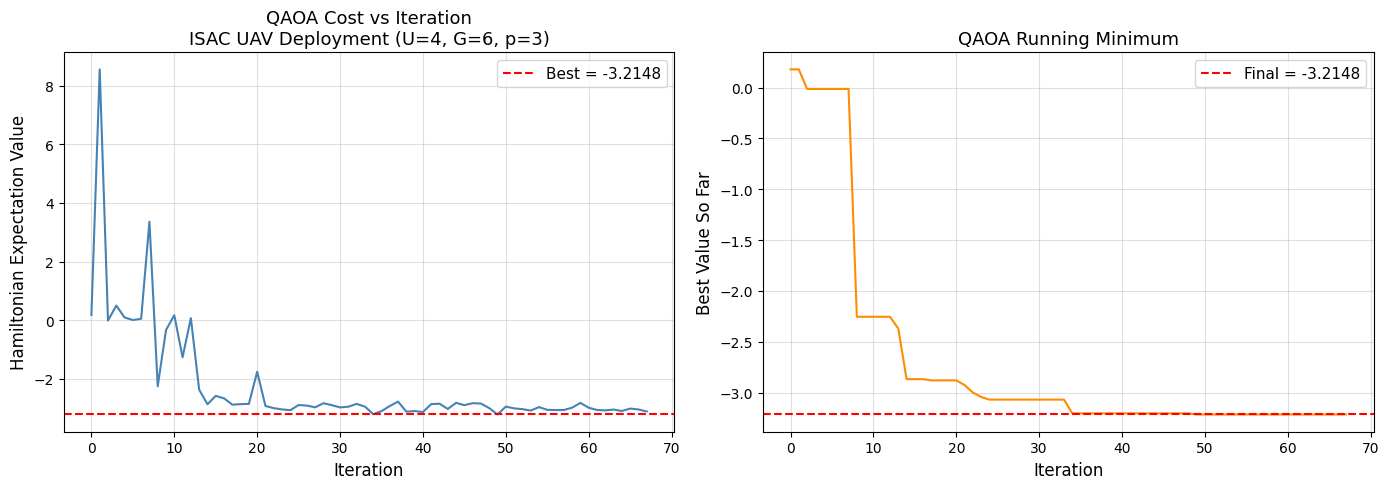

Total iterations : 68
Initial cost     : 0.1783  (Ising)
Final cost       : -3.1131  (Ising)
Best cost        : -3.2148  (Ising)


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(objective_func_vals, linewidth=1.5, color='steelblue')
axes[0].axhline(y=result.fun, linestyle='--', linewidth=1.5, color='red',
                label=f'Best = {result.fun:.4f}')
axes[0].set_xlabel('Iteration',                     fontsize=12)
axes[0].set_ylabel('Hamiltonian Expectation Value', fontsize=12)
axes[0].set_title(f'QAOA Cost vs Iteration\nISAC UAV Deployment (U={U}, G={G}, p={REPS})',
                  fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

running_min = np.minimum.accumulate(objective_func_vals)
axes[1].plot(running_min, linewidth=1.5, color='darkorange')
axes[1].axhline(y=result.fun, linestyle='--', linewidth=1.5, color='red',
                label=f'Final = {result.fun:.4f}')
axes[1].set_xlabel('Iteration',              fontsize=12)
axes[1].set_ylabel('Best Value So Far',      fontsize=12)
axes[1].set_title('QAOA Running Minimum', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_convergence.pdf', dpi=200, bbox_inches='tight')
plt.show()

print(f"Total iterations : {len(objective_func_vals)}")
print(f"Initial cost     : {objective_func_vals[0]:.4f}  (Ising)")
print(f"Final cost       : {objective_func_vals[-1]:.4f}  (Ising)")
print(f"Best cost        : {min(objective_func_vals):.4f}  (Ising)")

# Sample Optimised Circuit & Decode Best Bitstring (FIXED)


In [ ]:
from qiskit import transpile


opt_circuit      = candidate_circuit.assign_parameters(result.x)
measured_circuit = opt_circuit.measure_all(inplace=False)

shots            = 16384 if BACKEND_MODE == 'simulator' else HW_SHOTS
compiled_circuit = transpile(measured_circuit, backend)

print(f"Sampling on backend: {backend.name}  [{BACKEND_MODE}]  shots={shots}")
job    = backend.run(compiled_circuit, shots=shots)
counts = job.result().get_counts()

print(f"Total sampled bitstrings : {len(counts)}")
print(f"Total shots              : {shots}")

# ── Decode each bitstring ─────────────────────────────────────────────
def bitstring_to_x(bitstring):
    return np.array([int(b) for b in bitstring[::-1]], dtype=float)

best_obj      = np.inf; best_x      = None; best_bs      = None; best_cnt      = 0
best_feas_obj = np.inf; best_feas_x = None; best_feas_bs = None; best_feas_cnt = 0

for bitstring, count in counts.items():
    xv           = bitstring_to_x(bitstring)
    obj          = qubo_val(xv)
    c1,c2,c3,c4 = check_constraints(xv)

    if obj < best_obj:
        best_obj = obj; best_x = xv.copy(); best_bs = bitstring; best_cnt = count

    if c1 and c2 and c4 and obj < best_feas_obj:
        best_feas_obj = obj; best_feas_x = xv.copy()
        best_feas_bs = bitstring; best_feas_cnt = count

print("\n" + "="*60)
print("  FINAL RESULT — BEST SAMPLED QAOA SOLUTION")
print("="*60)
print(f"  Best sampled bitstring  : {best_bs}")
print(f"  Best sampled count      : {best_cnt}")
print(f"  Best sampled QUBO value : {best_obj:.6f}")

if best_feas_x is not None:
    feas_mat  = best_feas_x.reshape(U,G)
    feas_rate = sum_rate(feas_mat)

    print(f"\n  Best FEASIBLE bitstring : {best_feas_bs}")
    print(f"  Count                   : {best_feas_cnt}")
    print(f"  QUBO value              : {best_feas_obj:.6f}")
    print(f"  Sum-rate                : {feas_rate:.4e} bps")
    print(f"\n  Placement matrix (U×G):")
    print(feas_mat)

   
    print(f"\n  Brute-force QUBO        : {best_feas_obj_bruteforce:.6f}")
    print(f"  QAOA sampled QUBO       : {best_feas_obj:.6f}")

    AR      = best_feas_obj / best_feas_obj_bruteforce if best_feas_obj_bruteforce != 0 else 1.0
    AR_rate = feas_rate / bruteforce_rate if bruteforce_rate > 0 else 1.0
    print(f"  Approximation ratio (QUBO) : {AR:.4f}")
    print(f"  Approximation ratio (rate) : {AR_rate:.4f}")
    quality = ('Near-optimal' if abs(AR-1)<0.05 else
               'Good'        if abs(AR-1)<0.20 else
               'Acceptable'  if abs(AR-1)<0.40 else 'Needs tuning')
    print(f"  Result quality             : {quality}")
else:
    print("\n  No feasible solution found in sampled results.")
    print("  Try increasing shots, REPS, maxiter, or penalty weights.")
print("="*60)

# Store for Cell 9
qaoa_feas_x    = best_feas_x
qaoa_feas_rate = sum_rate(best_feas_x.reshape(U,G)) if best_feas_x is not None else 0.0
qaoa_feas_obj  = best_feas_obj


Sampling on backend: aer_simulator_statevector  [simulator]  shots=16384
Total sampled bitstrings : 16164
Total shots              : 16384

  FINAL RESULT — BEST SAMPLED QAOA SOLUTION
  Best sampled bitstring  : 010000001000000001000010
  Best sampled count      : 1
  Best sampled QUBO value : -73821667.821035

  Best FEASIBLE bitstring : 010000001000000001000010
  Count                   : 1
  QUBO value              : -73821667.821035
  Sum-rate                : 2.2303e+06 bps

  Placement matrix (U×G):
[[0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]]

  Brute-force QUBO        : -73882394.802618
  QAOA sampled QUBO       : -73821667.821035
  Approximation ratio (QUBO) : 0.9992
  Approximation ratio (rate) : 0.9717
  Result quality             : Near-optimal


#  Classical Baselines (FIXED)


In [86]:
# ── 8A: Greedy baseline — max marginal sum-rate ───────────────────────
# FIX: the original greedy did not enforce C2 (no co-location) DURING
# the search — it only reported C2 as a post-hoc feasibility flag. This
# allowed greedy to "cheat" by placing two UAVs at the same grid point
# if that scored higher on raw sum-rate, producing impossible
# Approximation Ratios (>1.0) when compared against the constrained
# QUBO optimum. The fix: skip already-occupied grid points during the
# greedy search, exactly as the QUBO's C2 constraint requires.
x_greedy = np.zeros((U,G), dtype=int)
occupied_grids = set()
for u in range(U):
    best_g, best_r = None, -np.inf
    for g in range(G):
        if g in occupied_grids:
            continue   # C2 enforcement
        x_greedy[u,g] = 1
        r = sum_rate(x_greedy)
        if r > best_r: best_r, best_g = r, g
        x_greedy[u,g] = 0
    x_greedy[u, best_g] = 1
    occupied_grids.add(best_g)

xv_greedy       = x_greedy.flatten().astype(float)
greedy_rate     = sum_rate(x_greedy)
greedy_obj      = qubo_val(xv_greedy)
g_c1,g_c2,g_c3,g_c4 = check_constraints(xv_greedy)

print("GREEDY BASELINE (max marginal rate, C2-enforced)")
print(x_greedy)
print(f"  Sum-rate  : {greedy_rate:.4e} bps")
print(f"  QUBO val  : {greedy_obj:.6f}")
print(f"  C1={g_c1} C2={g_c2} C3={g_c3} C4={g_c4}")

# ── 8B: Random baseline — Monte Carlo average ─────────────────────────
# Also fixed to enforce C2: skip already-occupied grids per trial,
# instead of allowing random co-location.
rng_rand   = np.random.default_rng(0)
rand_rates = []
for _ in range(500):
    xr = np.zeros((U,G), dtype=int)
    occ = set()
    for u in range(U):
        choices = [g for g in range(G) if g not in occ]
        g_pick = rng_rand.choice(choices)
        xr[u, g_pick] = 1
        occ.add(g_pick)
    rand_rates.append(sum_rate(xr))

rand_mean = float(np.mean(rand_rates))
rand_std  = float(np.std(rand_rates))
print(f"\nRANDOM BASELINE (500 trials, C1+C2-feasible)")
print(f"  Mean rate : {rand_mean:.4e} ± {rand_std:.2e} bps")

# Store for Cell 9
greedy_result = {'rate': greedy_rate, 'obj': greedy_obj,
                 'feasible': g_c1 and g_c2 and g_c4}
random_result = {'mean_rate': rand_mean, 'std_rate': rand_std}


GREEDY BASELINE (max marginal rate, C2-enforced)
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]]
  Sum-rate  : 2.1672e+06 bps
  QUBO val  : -73752195.689641
  C1=True C2=True C3=True C4=True

RANDOM BASELINE (500 trials, C1+C2-feasible)
  Mean rate : 1.5974e+06 ± 3.99e+05 bps


#  Comparison Table & Bar Chart (FIXED)


──────────────────────────────────────────────────────────────────────
Method                    Rate (bps)   AR_rate      QUBO val  Feasible
──────────────────────────────────────────────────────────────────────
Brute-force*              2.2953e+06    1.0000  -73882394.8026         ✓
Greedy                    2.1672e+06    0.9442  -73752195.6896         ✓
Random (mean)             1.5974e+06    0.6959           —           ?
QAOA (p=3)                2.2303e+06    0.9717  -73821667.8210         ✓
──────────────────────────────────────────────────────────────────────


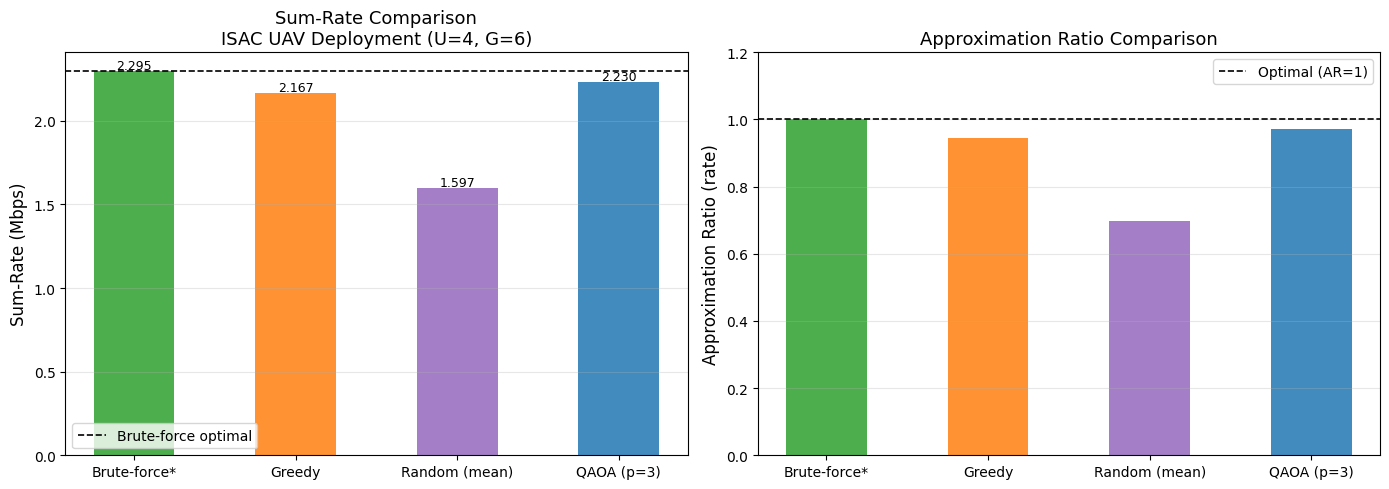


QAOA AR (rate) : 0.9717  (1.0 = optimal)
Greedy AR      : 0.9442
Random AR      : 0.6959


In [ ]:


qaoa_rate = qaoa_feas_rate if qaoa_feas_x is not None else 0.0
bf_rate   = bruteforce_rate

if bf_rate <= 0:
    raise RuntimeError(
        "bruteforce_rate is zero or unset — re-run Cell 3 before this cell."
    )
if qaoa_feas_x is None:
    print("WARNING: QAOA found no feasible solution in the sampled "
          "bitstrings (Cell 7). This usually means COBYLA did not "
          "converge (check 'Converged' flag in Cell 5's output) or "
          "shots/REPS are too low. QAOA's row below reflects this "
          "with AR=0.0 — increase MAXITER in Cell 5 and re-run.")

methods = {
    'Brute-force*' : {'rate': bf_rate,       'obj': best_feas_obj_bruteforce, 'feasible': True},
    'Greedy'        : {'rate': greedy_rate,   'obj': greedy_obj,
                       'feasible': greedy_result['feasible']},
    'Random (mean)' : {'rate': rand_mean,     'obj': float('nan'),    'feasible': None},
    f'QAOA (p={REPS})' : {'rate': qaoa_rate, 'obj': qaoa_feas_obj if qaoa_feas_x is not None else float('nan'),
                           'feasible': qaoa_feas_x is not None},
}

R_opt = bf_rate
F_opt = best_feas_obj_bruteforce

# ── Print table ───────────────────────────────────────────────────────
sep = "─" * 70
hdr = f"{'Method':<20}  {'Rate (bps)':>14}  {'AR_rate':>8}  {'QUBO val':>12}  {'Feasible':>8}"
print(sep); print(hdr); print(sep)
for name, info in methods.items():
    r    = info['rate'];  f = info['obj']
    ar_r = r / R_opt if R_opt > 0 else float('nan')
    ar_q = f / F_opt if (F_opt != 0 and not np.isnan(f)) else float('nan')
    ar_r = ar_r if r > 0 or name == 'Brute-force*' else float('nan')
    fe   = '✓' if info['feasible'] is True else ('✗' if info['feasible'] is False else '?')
    fstr = f"{f:.4f}" if not np.isnan(f) else "    —  "
    print(f"{name:<20}  {r:>14.4e}  {ar_r:>8.4f}  {fstr:>12}  {fe:>8}")
print(sep)

# ── Bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(methods.keys())
rates  = [methods[k]['rate']/1e6 for k in labels]
cols   = ['#2ca02c','#ff7f0e','#9467bd','#1f77b4']

bars = axes[0].bar(labels, rates, color=cols[:len(labels)], alpha=0.85, width=0.5)
axes[0].axhline(bf_rate/1e6, color='k', linestyle='--', linewidth=1.2,
                label='Brute-force optimal')
axes[0].set_ylabel('Sum-Rate (Mbps)', fontsize=12)
axes[0].set_title(f'Sum-Rate Comparison\nISAC UAV Deployment (U={U}, G={G})', fontsize=13)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max(rates),
                 f'{val:.3f}', ha='center', fontsize=9)

# AR plot
ar_vals = [methods[k]['rate']/R_opt for k in labels]
axes[1].bar(labels, ar_vals, color=cols[:len(labels)], alpha=0.85, width=0.5)
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1.2, label='Optimal (AR=1)')
axes[1].set_ylabel('Approximation Ratio (rate)', fontsize=12)
axes[1].set_title('Approximation Ratio Comparison', fontsize=13)
axes[1].set_ylim([0, 1.2])
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_comparison.pdf', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nQAOA AR (rate) : {qaoa_rate/R_opt:.4f}  (1.0 = optimal)")
print(f"Greedy AR      : {greedy_rate/R_opt:.4f}")
print(f"Random AR      : {rand_mean/R_opt:.4f}")